# Data Cleaning & EDA

In [3]:
!pip install gdown # installs python package gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gdown

url = f'https://drive.google.com/uc?id=1oD-nvRJui1X8rB4UcBFI65WAAIWd4LFz'
output = 'Austin_Weather_99_23.csv'
gdown.download(url, output, quiet=False)

file_path = output

Downloading...
From: https://drive.google.com/uc?id=1oD-nvRJui1X8rB4UcBFI65WAAIWd4LFz
To: /content/Austin_Weather_99_23.csv
100%|██████████| 525k/525k [00:00<00:00, 107MB/s]


Change 'file_path' based off of where the dataset is located in your gDrive. I recommend just making a copy of the dataset to your home gDrive (not in any folder) and naming it exactly 'Austin_Weather_99_23.csv'. If you wanna change the path feel free to do so and if it doesn't work just tell me and I can help fix it

In [4]:

data = pd.read_csv(file_path)
data.shape

orig_data = data.copy() # store original df to check with later

### Missing counts & other basic stuff

In [5]:
data.isnull().sum()  # missing counts for each column

,0
Date,0
TempHighF,0
TempLowF,0
TempAvgF,0
DewPointAvgF,4
HumidityAvgPercent,1
sealevelpressure,0
VisibilityAvgMiles,4
PrecipitationSumInches,204
Events,6318


In [6]:
data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


In [7]:
data.describe()

,TempHighF,TempLowF,TempAvgF,PrecipitationSumInches
count,10354.000000,10354.000000,10354.000000,10150.000000
mean,80.349189,59.701111,69.491733,0.094914
std,14.771837,14.523552,14.077261,0.360494
min,22.600000,8.200000,15.700000,0.000000
25%,71.000000,48.000000,59.200000,0.000000
50%,82.300000,62.850000,71.900000,0.000000
75%,92.000000,72.900000,81.400000,0.006000
max,110.400000,84.500000,95.100000,7.489000


In [8]:
# all numeric columns
numeric_columns = [
    'PrecipitationSumInches',
    'DewPointAvgF',
    'TempHighF',
    'TempAvgF',
    'TempLowF',
    'HumidityAvgPercent',
    'sealevelpressure',
    'VisibilityAvgMiles'
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce') # iterates thru, converts all to a numeric data type so no cleaning issues
    median_data = data[col].median() # get median
    data[col] = data[col].fillna(median_data) # fill empty values with median
    print("Column" , col, ":", median_data)

data.head()



Column PrecipitationSumInches : 0.0
Column DewPointAvgF : 60.6
Column TempHighF : 82.3
Column TempAvgF : 71.9
Column TempLowF : 62.849999999999994
Column HumidityAvgPercent : 66.5
Column sealevelpressure : 1015.6
Column VisibilityAvgMiles : 9.8


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,NaN


The above code just fills in all null values with the median. It's extremely modular so whenever we use different datasets we can just change the 'numeric_columns' table and put whatever columns we want there.

Note that we didn't touch the 'Events' column as there's only a qualitative values there. For the sake of cleaning let's assume that an empty value means 'sunny'. The code to fill in this special case is below

In [9]:
data['Events'] = data['Events'].fillna("sunny") # fills empty event with sunny. can change this later

data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,sunny
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,sunny
2,1/3/1999,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,sunny
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,sunny
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,sunny


Now, all data is fully cleaned, let's just confirm

In [10]:
data.isnull().sum()

,0
Date,0
TempHighF,0
TempLowF,0
TempAvgF,0
DewPointAvgF,0
HumidityAvgPercent,0
sealevelpressure,0
VisibilityAvgMiles,0
PrecipitationSumInches,0
Events,0


There are no null values as shown above so we can make some plots now and compare to orig_data.

Date                             0
TempHighF                        0
TempLowF                         0
TempAvgF                         0
DewPointAvgF                     0
HumidityAvgPercent               0
sealevelpressure                 0
VisibilityAvgMiles               0
PrecipitationSumInches           0
Events                           0
TempAvg7Day                      6
TempAvg30Day                    29
DewPointAvg7Day                  6
DewPointAvg30Day                29
HumidityAvgPercent7Day           6
HumidityAvgPercent30Day         29
TempHighF_7Day                   6
TempHighF_30Day                 29
TempLowF_7Day                    6
TempLowF_30Day                  29
TempAvgF_7Day                    6
TempAvgF_30Day                  29
DewPointAvgF_7Day                6
DewPointAvgF_30Day              29
HumidityAvgPercent_7Day          6
HumidityAvgPercent_30Day        29
sealevelpressure_7Day            6
sealevelpressure_30Day          29
VisibilityAvgMiles_7

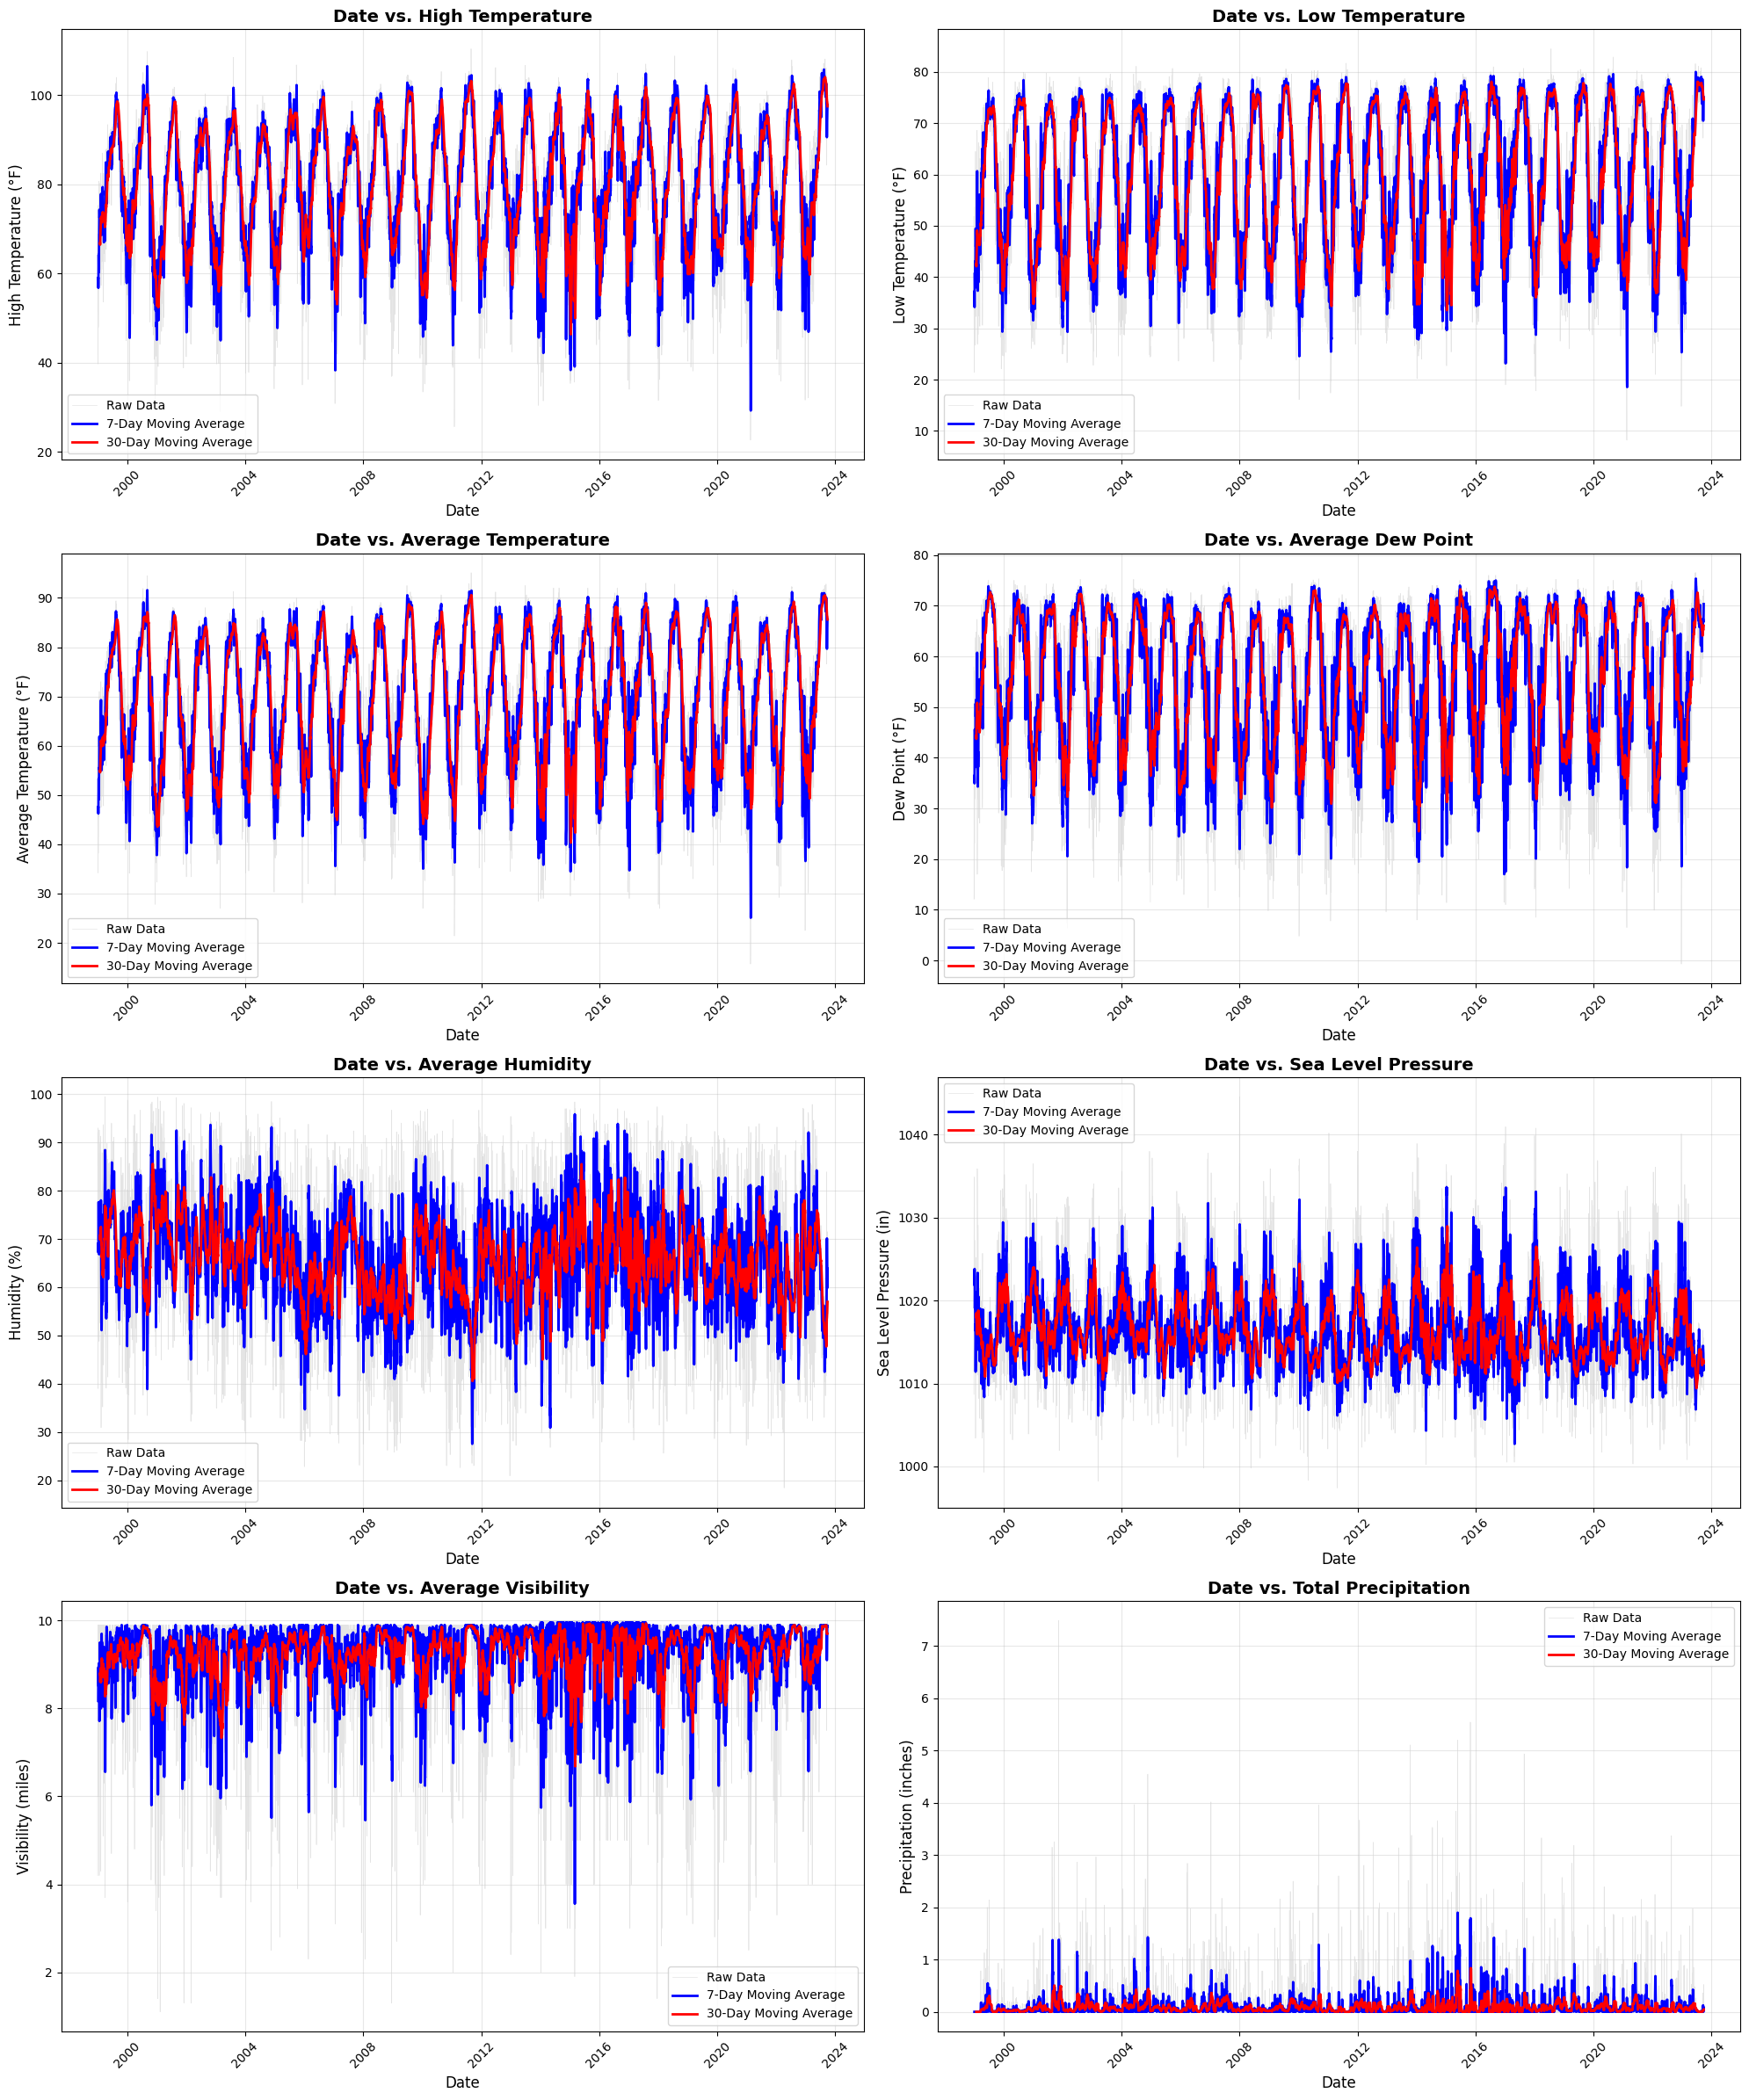

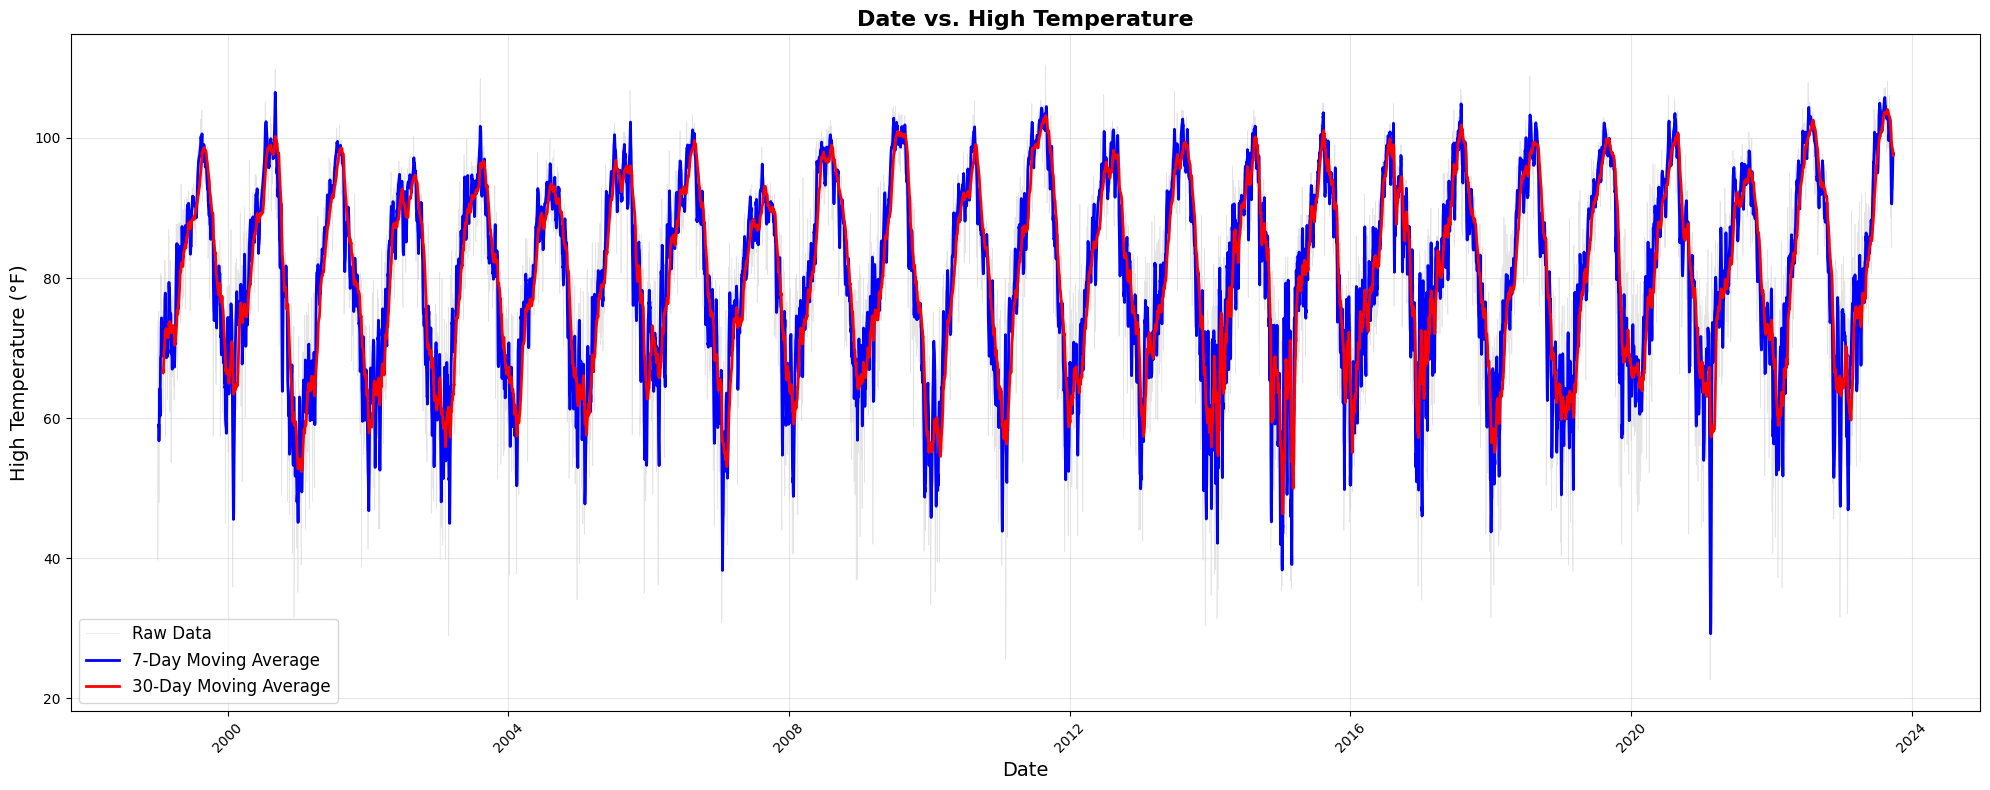

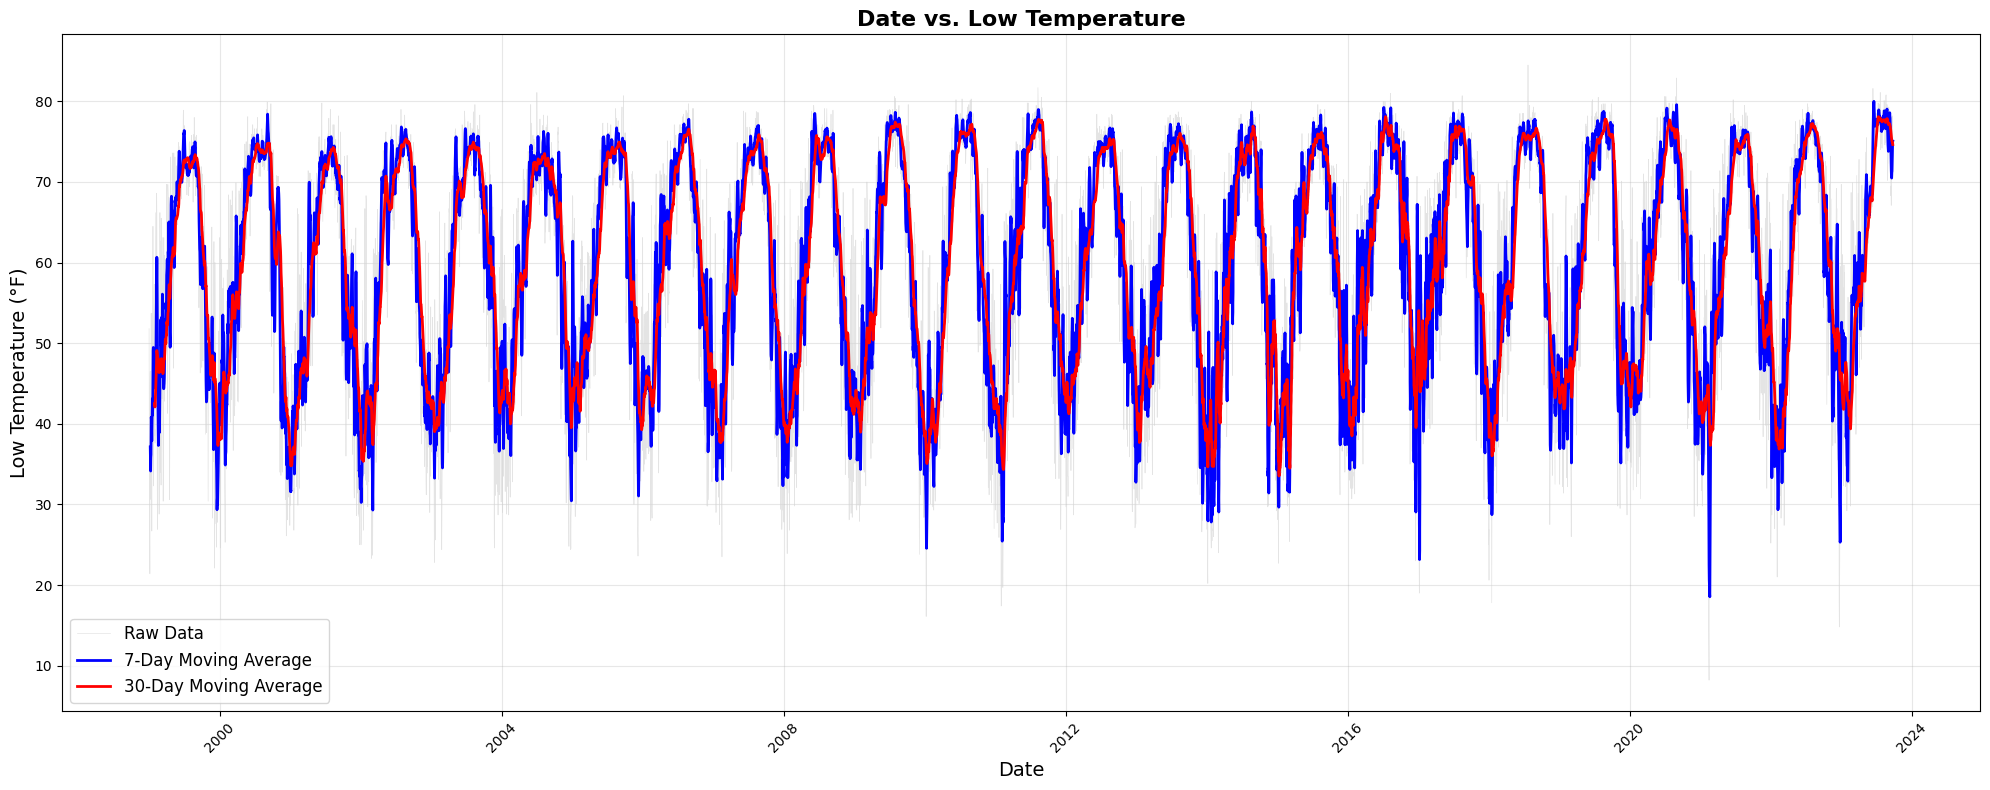

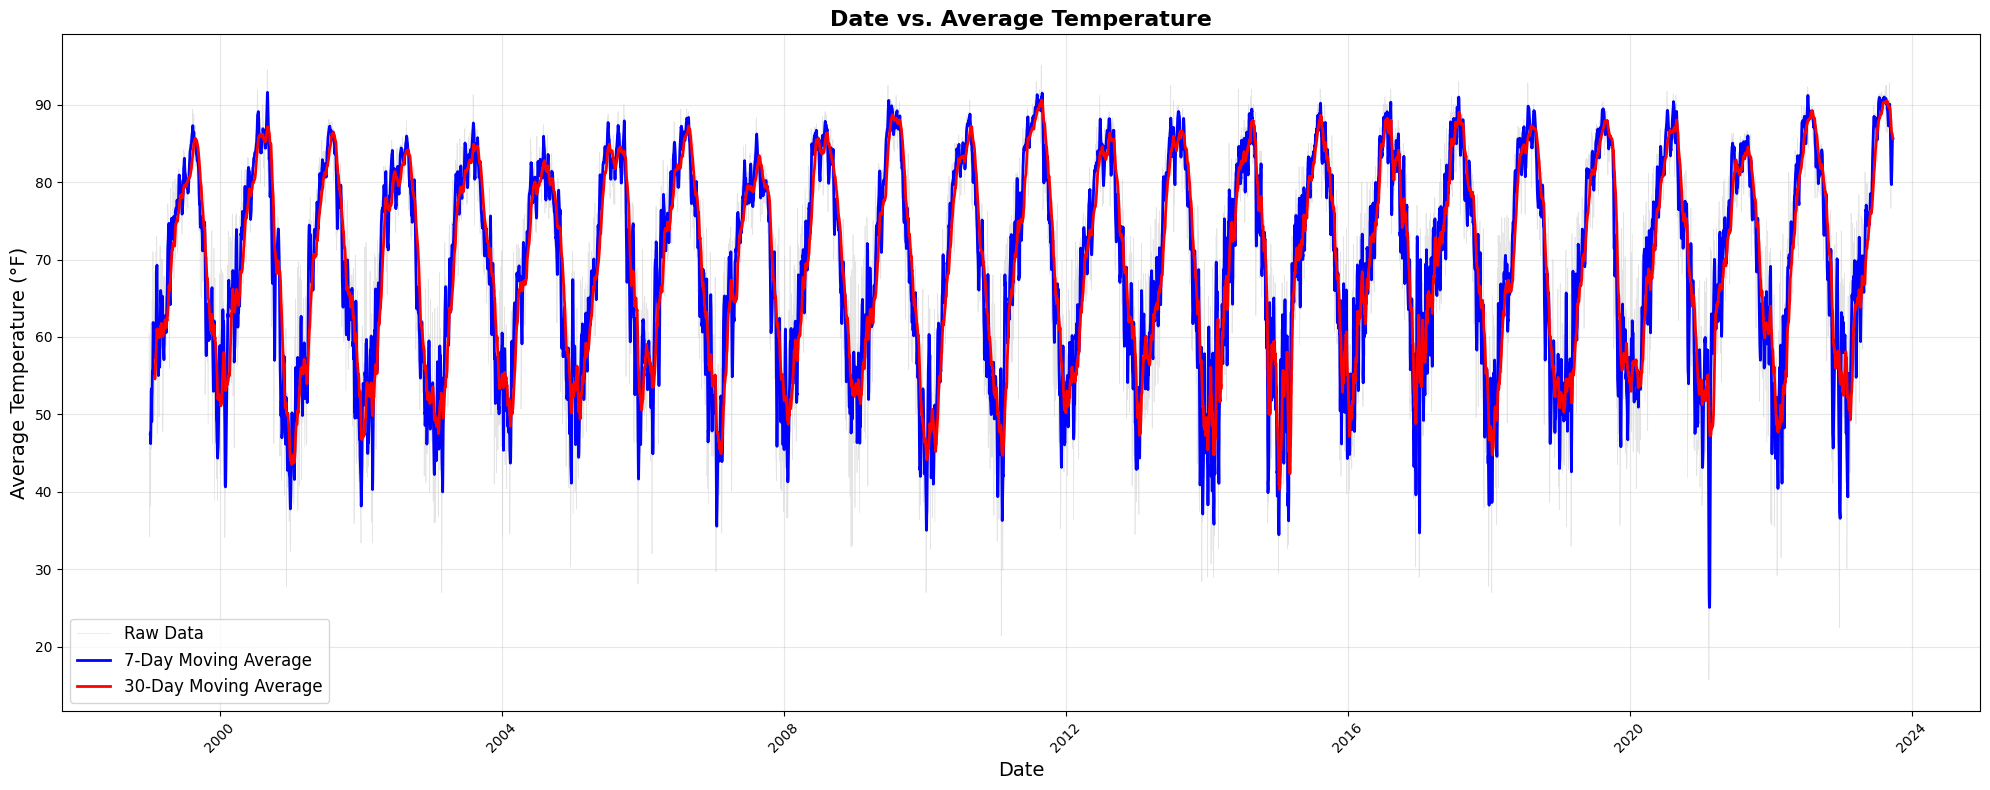

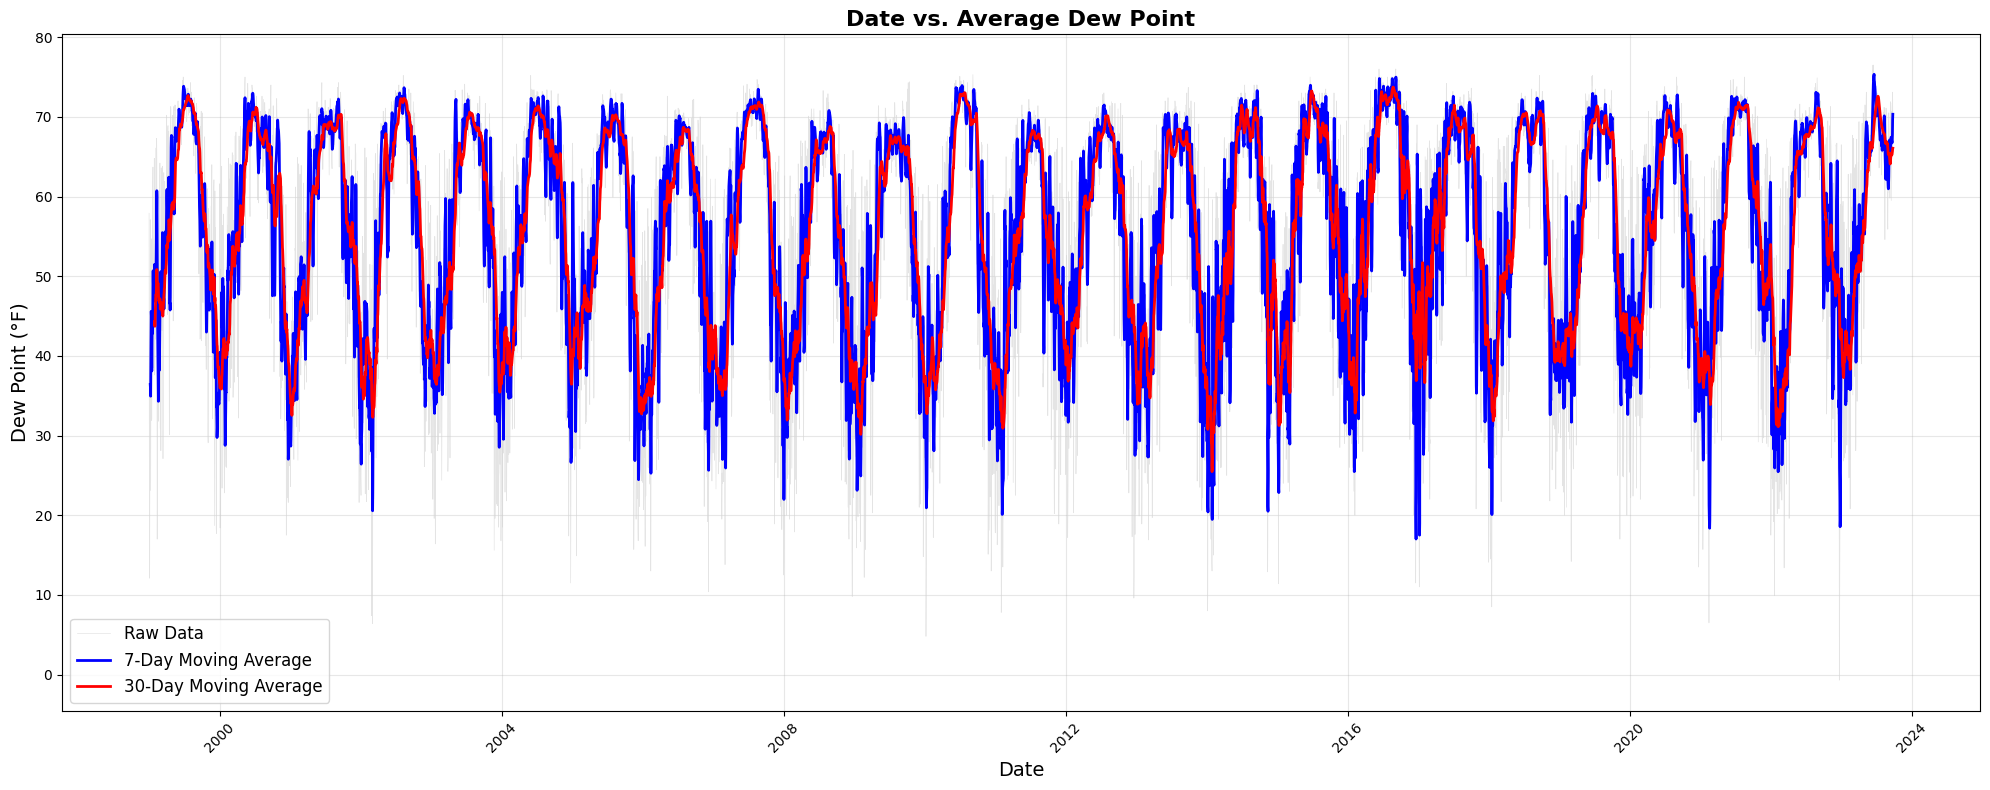

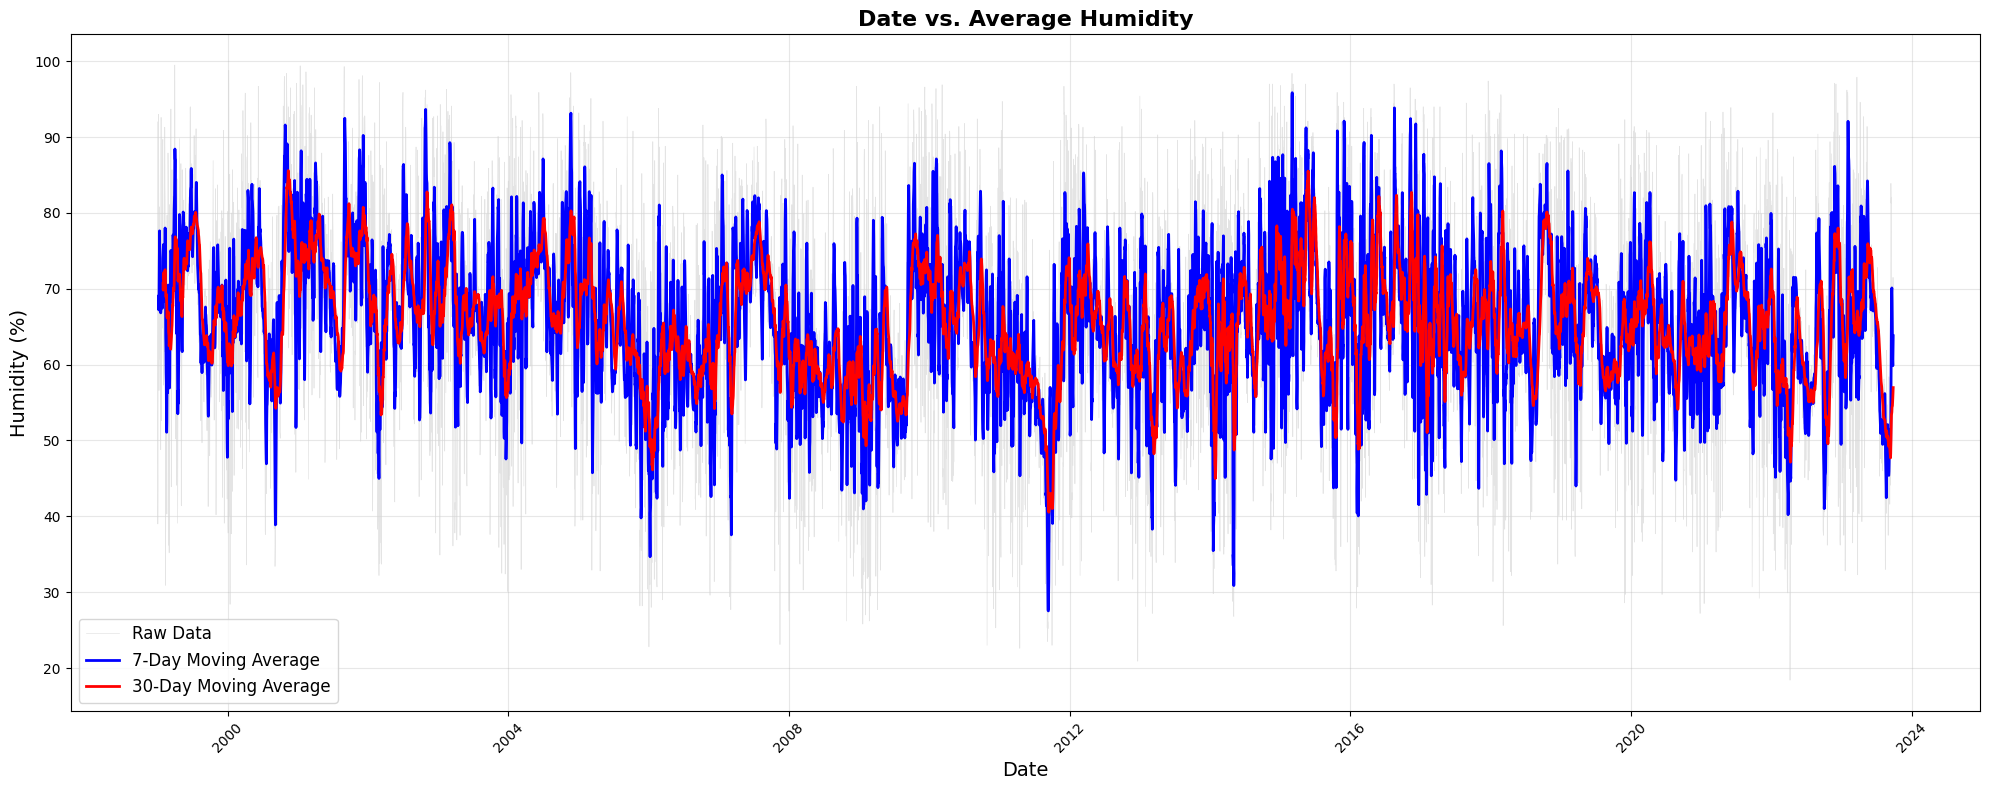

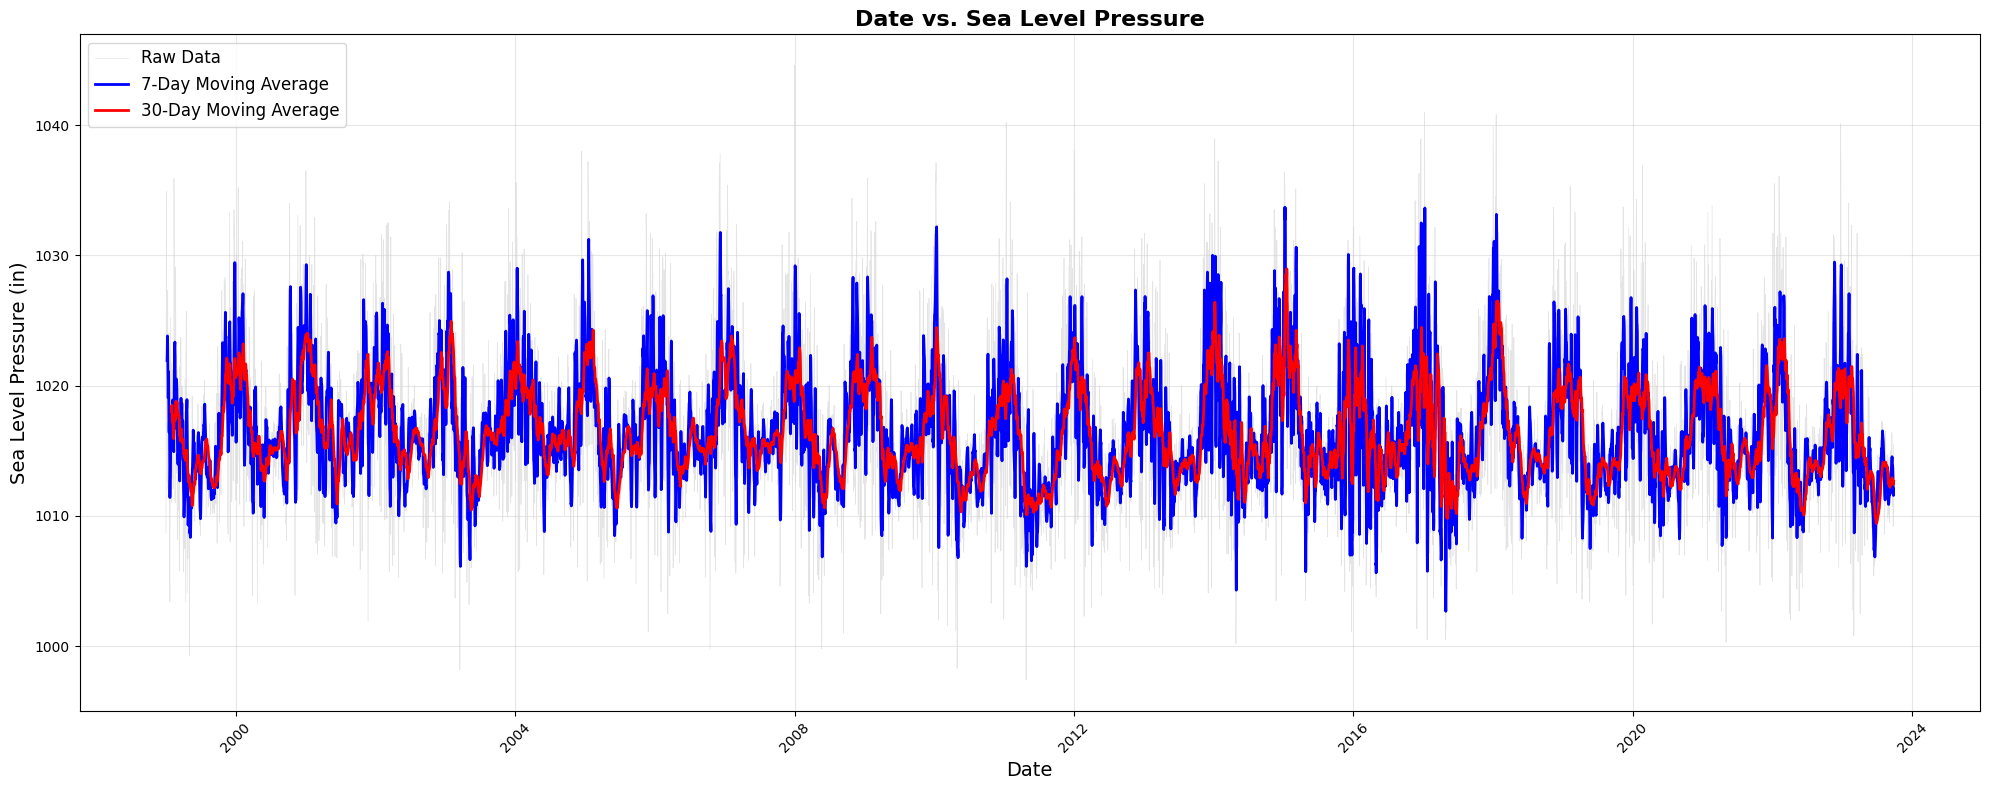

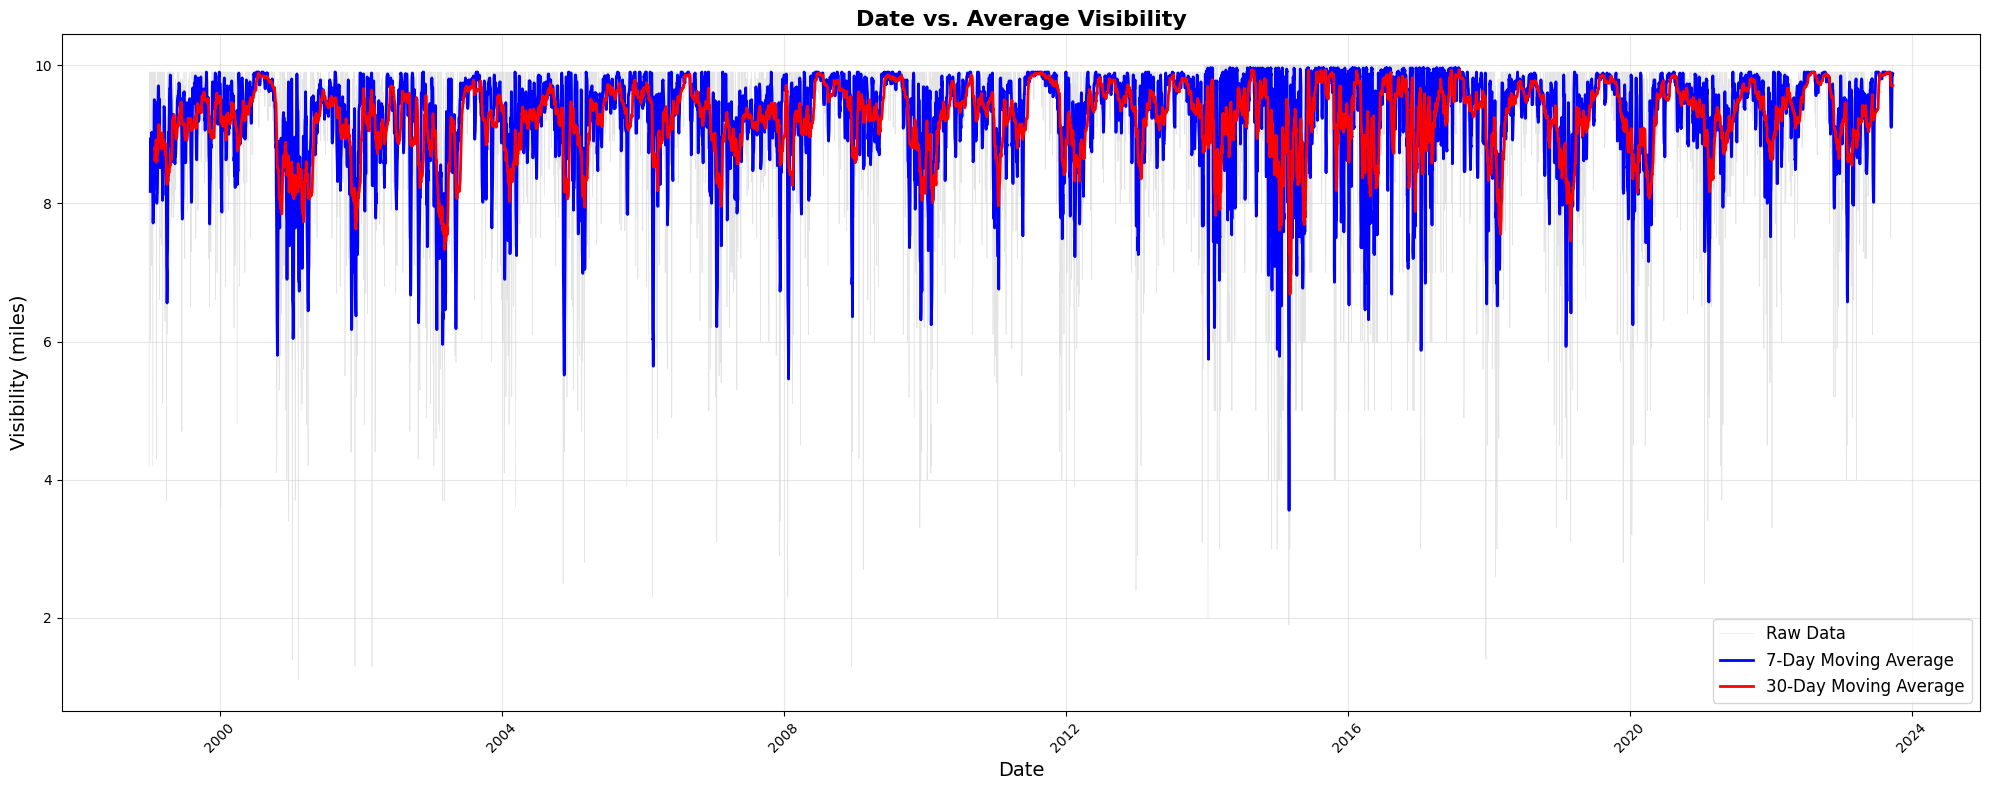

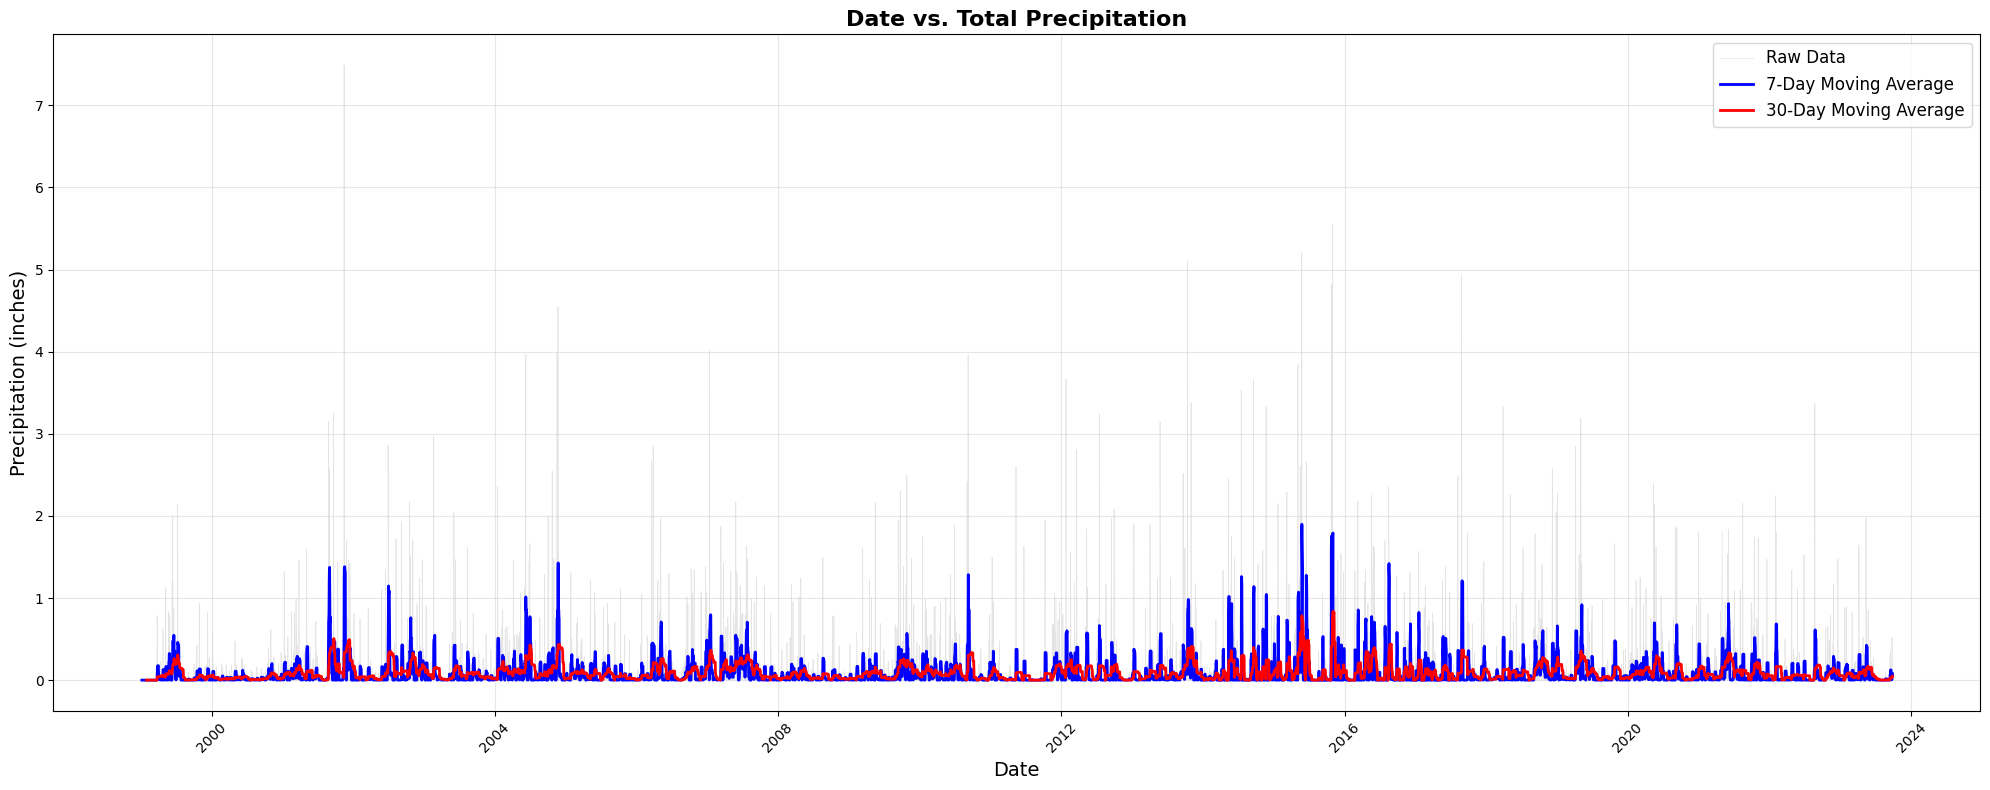

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Calculate 7-day and 30-day rolling averages for all variables
variables = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
             'HumidityAvgPercent', 'sealevelpressure',
             'VisibilityAvgMiles', 'PrecipitationSumInches']

for var in variables:
    data[f'{var}_7Day'] = data[var].rolling(window=7).mean()
    data[f'{var}_30Day'] = data[var].rolling(window=30).mean()

# Check for null values
print(data.isnull().sum())
print("\nFirst few rows:")
print(data.head())

# Create individual plots for each variable
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()

# Plot settings for each variable
plot_configs = [
    ('TempHighF', 'High Temperature (°F)', 'Date vs. High Temperature'),
    ('TempLowF', 'Low Temperature (°F)', 'Date vs. Low Temperature'),
    ('TempAvgF', 'Average Temperature (°F)', 'Date vs. Average Temperature'),
    ('DewPointAvgF', 'Dew Point (°F)', 'Date vs. Average Dew Point'),
    ('HumidityAvgPercent', 'Humidity (%)', 'Date vs. Average Humidity'),
    ('sealevelpressure', 'Sea Level Pressure (in)', 'Date vs. Sea Level Pressure'),
    ('VisibilityAvgMiles', 'Visibility (miles)', 'Date vs. Average Visibility'),
    ('PrecipitationSumInches', 'Precipitation (inches)', 'Date vs. Total Precipitation')
]

for idx, (var, ylabel, title) in enumerate(plot_configs):
    ax = axes[idx]

    # Plot raw data with thin line
    ax.plot(data['Date'], data[var], label='Raw Data',
            linewidth=0.5, alpha=0.6, color='lightgray')

    # Plot 7-day rolling average
    ax.plot(data['Date'], data[f'{var}_7Day'], label='7-Day Moving Average',
            linewidth=2, color='blue')

    # Plot 30-day rolling average
    ax.plot(data['Date'], data[f'{var}_30Day'], label='30-Day Moving Average',
            linewidth=2, color='red')

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Optional: Create individual full-size plots for each variable
for var, ylabel, title in plot_configs:
    plt.figure(figsize=(20, 8))

    plt.plot(data['Date'], data[var], label='Raw Data',
             linewidth=0.5, alpha=0.6, color='lightgray')
    plt.plot(data['Date'], data[f'{var}_7Day'], label='7-Day Moving Average',
             linewidth=2, color='blue')
    plt.plot(data['Date'], data[f'{var}_30Day'], label='30-Day Moving Average',
             linewidth=2, color='red')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
